# Monte Carlo Portfolio Simulation
This notebook uses historical market data to simulate portfolio trajectories, estimate **VAR** (Value at Risk) and **CVAR** (Conditional Value at Risk), and visualize the results.

In [207]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt

## Function definitions
Define helper functions to fetch market data and compute risk metrics.

## Data download
Select tickers and download historical closing prices to compute returns and covariance.

## Portfolio weights
Generate a random set of weights that sum to 1 for the portfolio allocation.

## Monte Carlo simulation
Simulate portfolio evolution across multiple scenarios using correlated asset returns.

In [208]:
def get_data(stocks, start_date, end_date):
    df = yf.download(stocks, start=start_date, end=end_date)    
    df = df["Close"]
    returns = df.pct_change()
    meanReturns = returns.mean()
    covMatrix = returns.cov()
    return meanReturns, covMatrix

def mcVAR(returns, alpha=5): # Value at risk 
    return np.percentile(returns, alpha)

def mcCVAR(returns, alpha=5): # Value at risk 
    isBellowVAR = returns <= mcVAR(returns, alpha=alpha)
    return returns[isBellowVAR].mean()
   

## Risk metrics
Compute portfolio-level VAR and CVAR from the distribution of final simulated values.

In [209]:
stocks_list = ["AAPL", "NVDA","MSFT", "GOOGL","JPM", "GS","KO", "WMT","XOM","TSLA"]

end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(300)

meanReturns, covMatrix = get_data(stocks=stocks_list, start_date=start_date, end_date=end_date)
print(f' Mean Returns : \n {meanReturns}')
print(f'----------------------------------')
print(f' Covariance Matrix : \n {covMatrix}')

[*********************100%***********************]  10 of 10 completed

 Mean Returns : 
 Ticker
AAPL     0.001066
GOOGL    0.002540
GS       0.001675
JPM      0.000508
KO       0.000511
MSFT    -0.001116
NVDA     0.000956
TSLA     0.000775
WMT      0.001190
XOM      0.002740
dtype: float64
----------------------------------
 Covariance Matrix : 
 Ticker      AAPL     GOOGL        GS           JPM        KO      MSFT  \
Ticker                                                                   
AAPL    0.000196  0.000075  0.000072  4.740578e-05  0.000006  0.000019   
GOOGL   0.000075  0.000294  0.000077  5.089083e-05 -0.000010  0.000029   
GS      0.000072  0.000077  0.000285  1.570537e-04 -0.000029  0.000060   
JPM     0.000047  0.000051  0.000157  1.810575e-04 -0.000013  0.000039   
KO      0.000006 -0.000010 -0.000029 -1.288259e-05  0.000096 -0.000029   
MSFT    0.000019  0.000029  0.000060  3.854672e-05 -0.000029  0.000208   
NVDA    0.000066  0.000104  0.000141  7.764550e-05 -0.000051  0.000110   
TSLA    0.000106  0.000174  0.000125  1.060286e-04 -0.00

In [210]:
weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)
print(f'Our random weights : \n {weights}')
print(f'Sum of our weights must be 1 : \n {np.round(np.sum(weights))}')

Our random weights : 
 [0.04531262 0.13532867 0.04269907 0.12773347 0.09001633 0.10172946
 0.12275518 0.11932868 0.08140254 0.13369398]
Sum of our weights must be 1 : 
 1.0


In [211]:
nb_simulations = 10000
timeframe = 100 # Our timeframe of 100 days

mean_returns_matrix = np.full(shape=(timeframe, len(weights)), fill_value=meanReturns)
mean_returns_matrix = mean_returns_matrix.T

portfolio_simulations = np.full(shape=(timeframe, nb_simulations), fill_value=0.0)

start_value = 10_000

for m in range(0, nb_simulations):
    Z = np.random.normal(size=(timeframe, len(weights)))
    L = np.linalg.cholesky(covMatrix)

    portfolioReturns = mean_returns_matrix + np.inner(L, Z)
    portfolio_simulations[:,m] = np.cumprod(np.inner(weights, portfolioReturns.T) + 1) * start_value

In [212]:
portfolios_results = pd.Series(portfolio_simulations[-1,:])

var = start_value - mcVAR(returns=portfolios_results, alpha=5)
cvar = start_value - mcCVAR(returns=portfolios_results, alpha=5)

print(var, cvar)

261.1491444046187 579.663206695508


## Visualization
Plot a subset of simulated portfolio paths and overlay key risk levels.

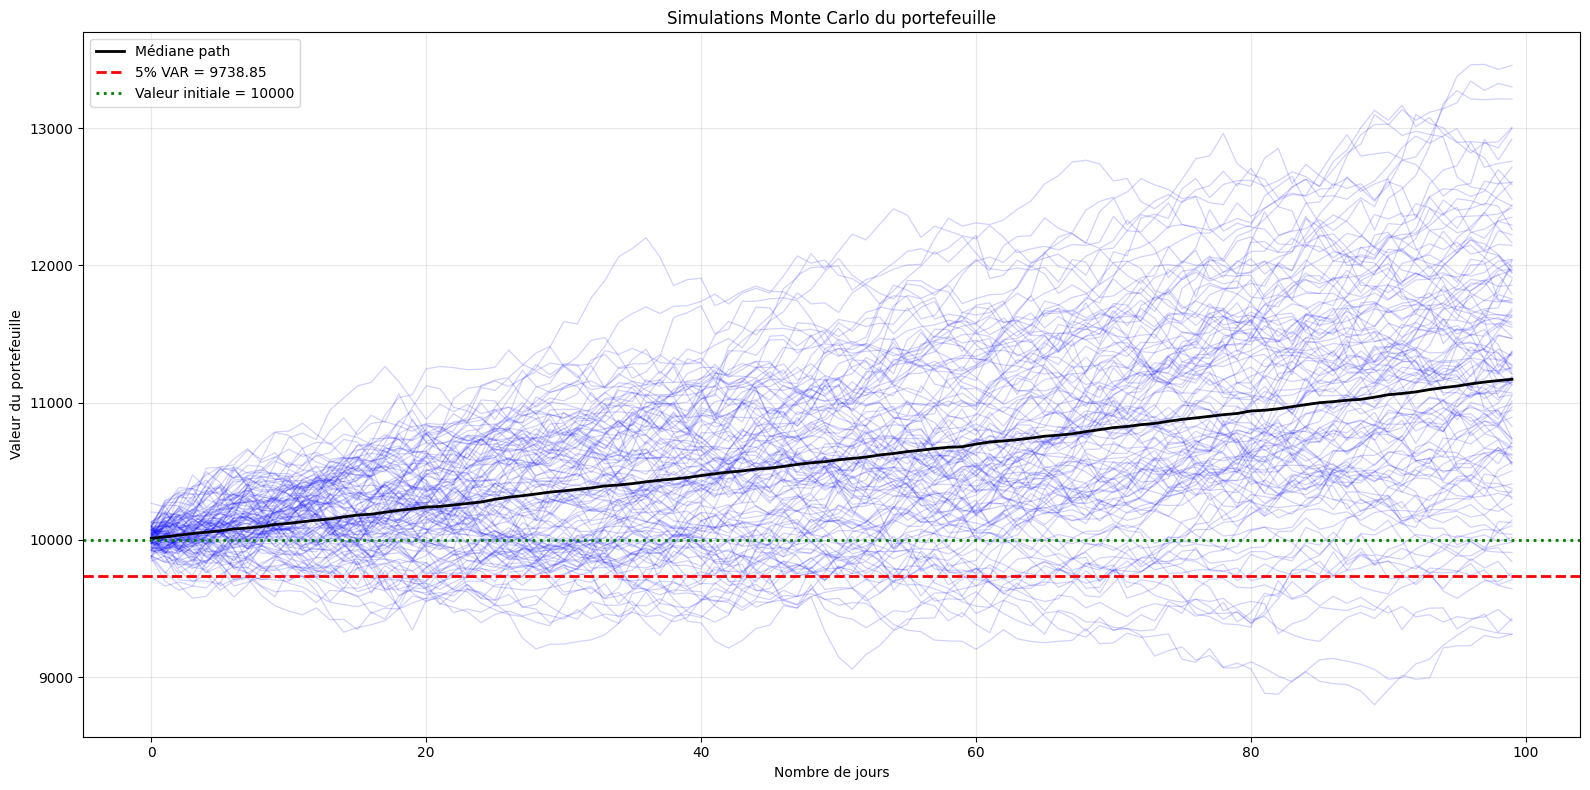

In [213]:
var_line = mcVAR(returns=portfolios_results, alpha=5)

subset_index = np.random.choice(portfolio_simulations.shape[1], size=min(120, portfolio_simulations.shape[1]), replace=False)
subset_simulations = portfolio_simulations[:, subset_index]
median_path = np.median(portfolio_simulations, axis=1)
quantile_5 = np.percentile(portfolio_simulations, 5, axis=1)
quantile_95 = np.percentile(portfolio_simulations, 95, axis=1)

plt.figure(figsize=(16,8))
plt.plot(subset_simulations, color="blue", alpha=0.18, linewidth=0.9)
plt.plot(median_path, color="black", linewidth=2, label="Médiane path")

plt.axhline(y=var_line, color="red", linestyle="--", linewidth=2, label=f"5% VAR = {var_line:.2f}")
plt.axhline(y=start_value, color="green", linestyle=":", linewidth=2, label=f"Valeur initiale = {start_value}")

plt.title("Simulations Monte Carlo du portefeuille")
plt.xlabel("Nombre de jours")
plt.ylabel("Valeur du portefeuille")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
median_path[-1]

np.float64(11170.031883849984)

## Tail risk simulation
Repeat the Monte Carlo simulation with heavier-tailed returns to observe extreme-loss behavior.

In [215]:
nb_simulations = 10000
timeframe = 100 # Our timeframe of 100 days

mean_returns_matrix = np.full(shape=(timeframe, len(weights)), fill_value=meanReturns)
mean_returns_matrix = mean_returns_matrix.T

portfolio_simulations = np.full(shape=(timeframe, nb_simulations), fill_value=0.0)

start_value = 10_000

for m in range(0, nb_simulations):
    Z = np.random.standard_t(3, size=(timeframe, len(weights))) # Tail Risk simulation
    L = np.linalg.cholesky(covMatrix)

    portfolioReturns = mean_returns_matrix + np.inner(L, Z)
    portfolio_simulations[:,m] = np.cumprod(np.inner(weights, portfolioReturns.T) + 1) * start_value

In [216]:
portfolios_results = pd.Series(portfolio_simulations[-1,:])

var = start_value - mcVAR(returns=portfolios_results, alpha=5)
cvar = start_value - mcCVAR(returns=portfolios_results, alpha=5)

print(var, cvar)

1192.7728380632216 1741.3413278968546


## Tail risk visualization
Plot the tail-risk simulation results and compare with the initial capital benchmark.

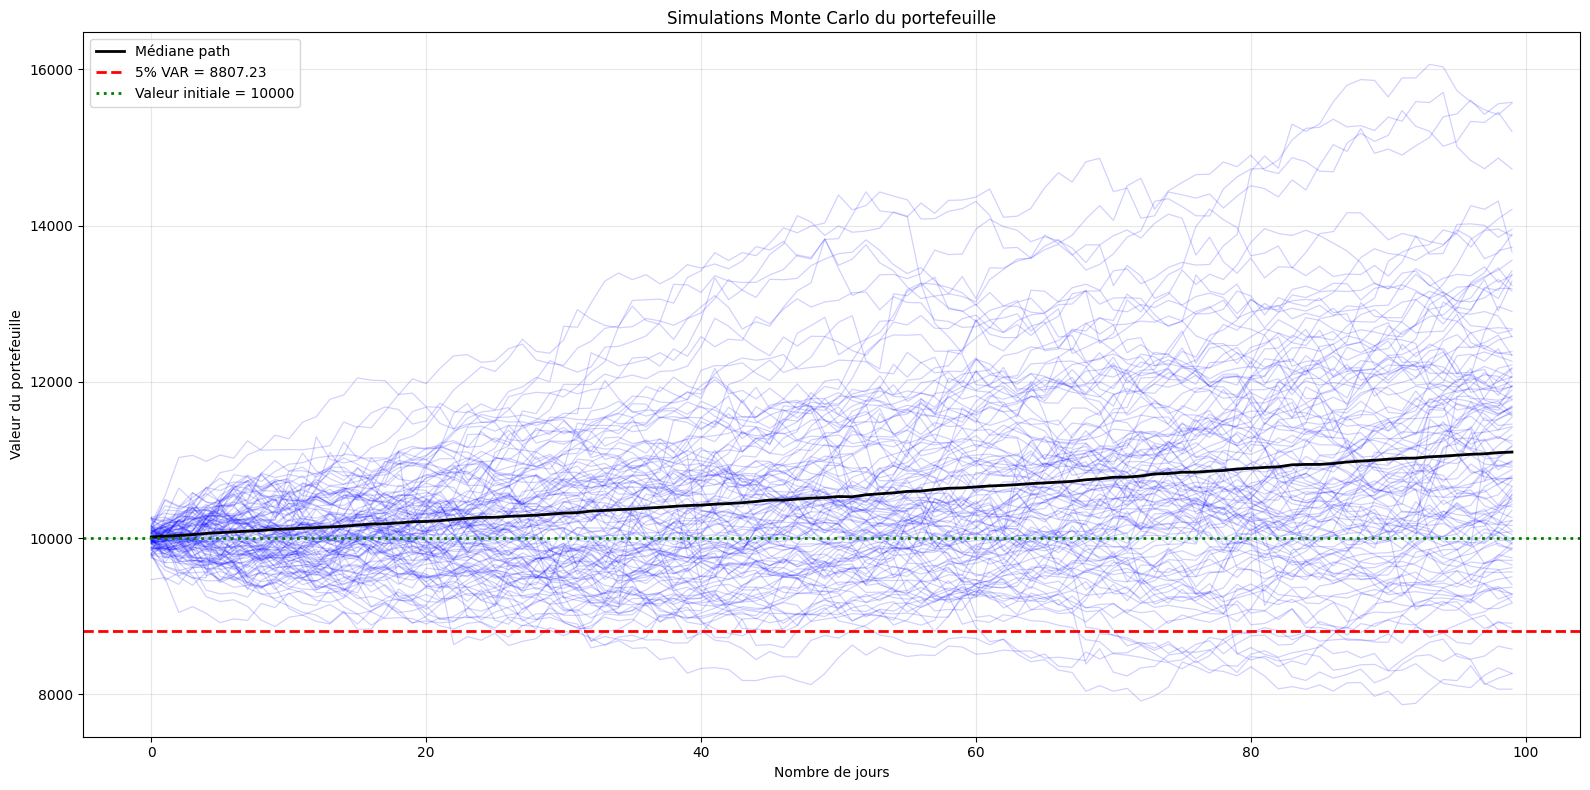

In [217]:
var_line = mcVAR(returns=portfolios_results, alpha=5)

subset_index = np.random.choice(portfolio_simulations.shape[1], size=min(120, portfolio_simulations.shape[1]), replace=False)
subset_simulations = portfolio_simulations[:, subset_index]
median_path = np.median(portfolio_simulations, axis=1)
quantile_5 = np.percentile(portfolio_simulations, 5, axis=1)
quantile_95 = np.percentile(portfolio_simulations, 95, axis=1)

plt.figure(figsize=(16,8))
plt.plot(subset_simulations, color="blue", alpha=0.18, linewidth=0.9)
plt.plot(median_path, color="black", linewidth=2, label="Médiane path")

plt.axhline(y=var_line, color="red", linestyle="--", linewidth=2, label=f"5% VAR = {var_line:.2f}")
plt.axhline(y=start_value, color="green", linestyle=":", linewidth=2, label=f"Valeur initiale = {start_value}")

plt.title("Simulations Monte Carlo du portefeuille")
plt.xlabel("Nombre de jours")
plt.ylabel("Valeur du portefeuille")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [218]:
median_path[-1]

np.float64(11100.157739275402)